# Phase 1 — Exploratory Data Analysis

Financial Inclusion in Africa — `bank_account` prediction across Kenya,
Rwanda, Tanzania, Uganda.

Each section below maps to a numbered task in `Implementation_plan.md`
Phase 1, and ends with the **decision** it feeds into downstream. This
notebook only reads/explores — no transformation logic lives here (that's
`src/fin_inclusion/preprocessing/`, built in Phase 2 from these findings).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "config"))
from settings import load_settings

from fin_inclusion.data.loader import DataLoader
from fin_inclusion.data.validators import (
    cardinality_audit,
    check_key_uniqueness,
    check_train_test_category_consistency,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

settings = load_settings()
loader = DataLoader(raw_train_path=settings.paths.raw_train, raw_test_path=settings.paths.raw_test)
train = loader.load_train()
test = loader.load_test()

TARGET = settings.data.target_column
CATEGORICAL_COLS = [
    c for c in train.columns
    if train[c].dtype == "object" and c not in ("uniqueid", TARGET)
]

print(f"train: {train.shape}, test: {test.shape}")
print(f"categorical columns: {CATEGORICAL_COLS}")
train.head(3)

train: (23524, 13), test: (10086, 12)
categorical columns: ['country', 'location_type', 'cellphone_access', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']


,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed


## 1.1 — Per-country target distribution

bank_account,No,Yes
country,,
Kenya,74.9,25.1
Rwanda,88.5,11.5
Tanzania,90.8,9.2
Uganda,91.4,8.6


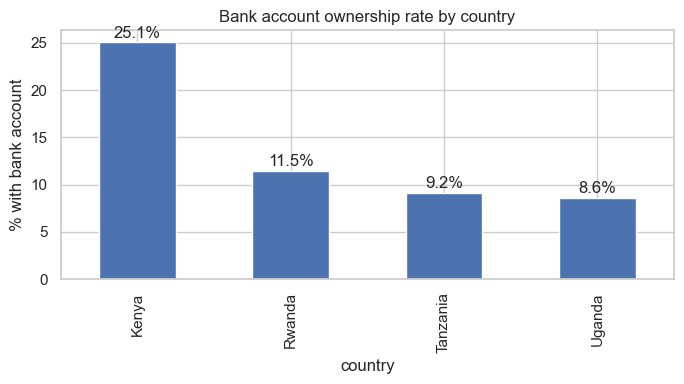

In [2]:
country_target_pct = (
    train.groupby("country")[TARGET]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct")
    .reset_index()
)
country_target_pct_pivot = country_target_pct.pivot(index="country", columns=TARGET, values="pct")
display(country_target_pct_pivot.round(1))

fig, ax = plt.subplots(figsize=(7, 4))
country_target_pct_pivot["Yes"].sort_values(ascending=False).plot.bar(ax=ax, color="#4C72B0")
ax.set_ylabel("% with bank account")
ax.set_title("Bank account ownership rate by country")
for i, v in enumerate(country_target_pct_pivot["Yes"].sort_values(ascending=False)):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
plt.tight_layout()
plt.show()

**Decision fed:** confirms the ~3x spread across countries (Kenya highest,
Uganda/Tanzania lowest) documented in `README.md` §3. This is the primary
justification for stratifying CV by country+target jointly (Phase 2.8) and
for reporting per-country metrics throughout (Phase 3.7, Phase 4.9).

## 1.2 — Per-country feature distributions

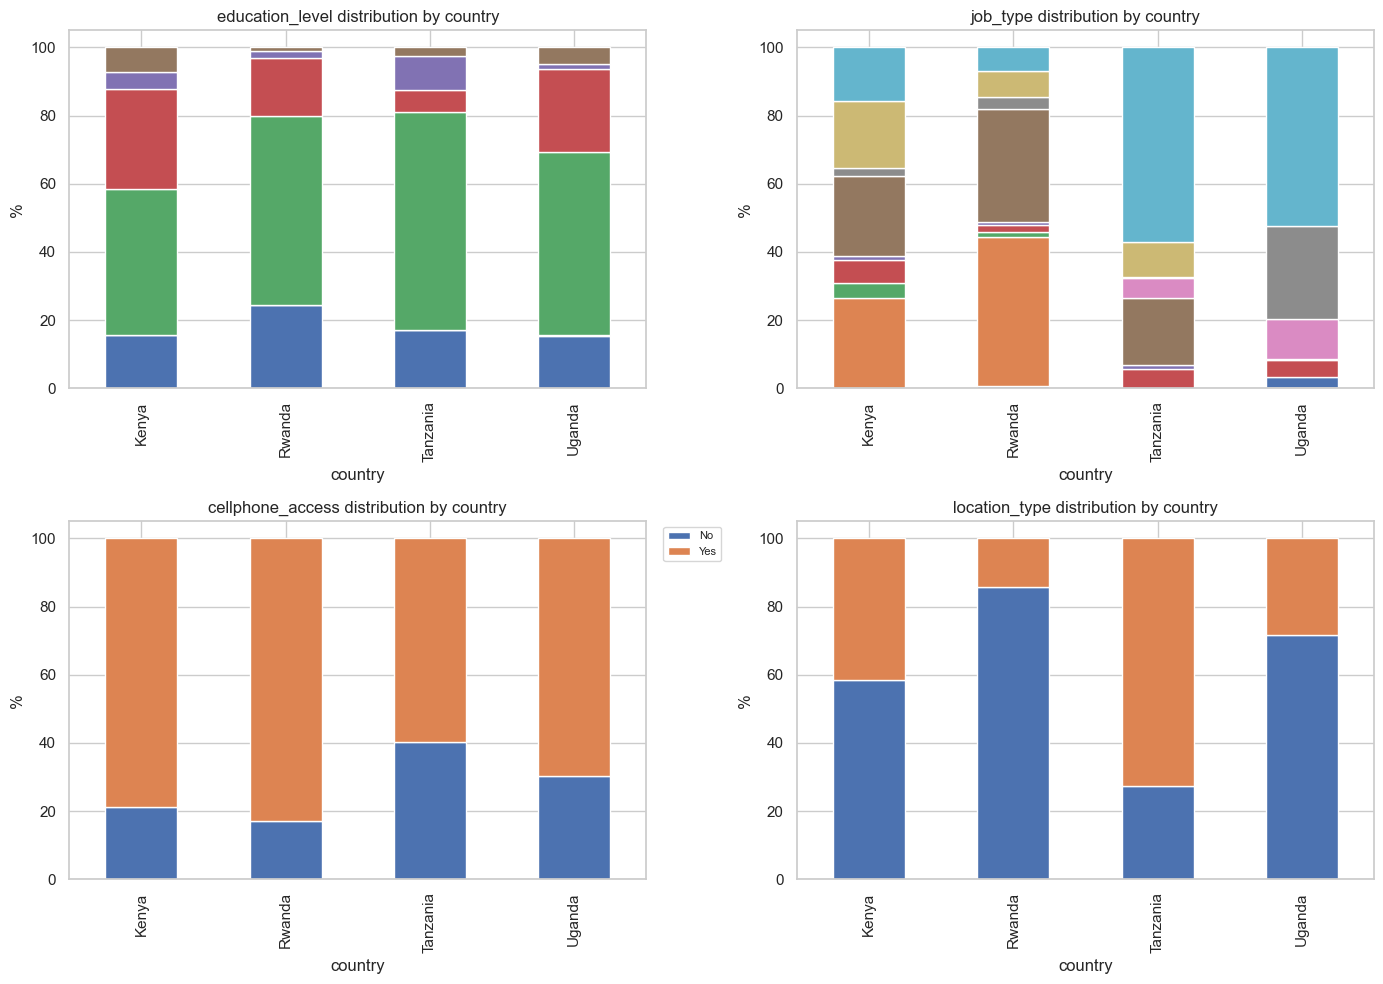

cellphone_access    No   Yes
country                     
Kenya             21.1  78.9
Rwanda            17.0  83.0
Tanzania          40.2  59.8
Uganda            30.3  69.7


In [3]:
feature_cols_to_check = ["education_level", "job_type", "cellphone_access", "location_type"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), feature_cols_to_check):
    ct = pd.crosstab(train["country"], train[col], normalize="index").mul(100)
    ct.plot.bar(stacked=True, ax=ax, legend=col == "cellphone_access")
    ax.set_title(f"{col} distribution by country")
    ax.set_ylabel("%")
    if col == "cellphone_access":
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print(pd.crosstab(train["country"], train["cellphone_access"], normalize="index").mul(100).round(1))

**Decision fed:** feature distributions genuinely differ by country —
e.g. cellphone access ranges from 59.8% (Tanzania) to 83.0% (Rwanda), with
Kenya at 78.9% — consistent with these being four separate national
surveys rather than one cross-sectional sample. Note this means cellphone
access alone doesn't explain Kenya's outsized account-ownership rate
(Rwanda has higher phone access but a much lower account rate), so
whatever drives Kenya's gap is more than phone access alone — plausibly
Kenya-specific mobile-money (M-Pesa) adoption on top of phone access,
which the pooled model can only capture through the `country` feature
itself, not through `cellphone_access`. This supports keeping `country`
as a pooled feature (real signal, not noise) and confirms per-country
reporting is meaningful rather than an artifact.

## 1.3 — Missingness-in-disguise correlation check

In [4]:
disguised_missing = {
    "marital_status": "Dont know",
    "education_level": "Other/Dont know/RTA",
    "job_type": "Dont Know/Refuse to answer",
}

target_yes_rate_overall = (train[TARGET] == "Yes").mean()
print(f"Overall 'Yes' rate: {target_yes_rate_overall:.1%}\n")

for col, placeholder in disguised_missing.items():
    mask = train[col] == placeholder
    n = mask.sum()
    if n == 0:
        continue
    rate = (train.loc[mask, TARGET] == "Yes").mean()
    print(f"{col} == '{placeholder}': n={n}, bank_account='Yes' rate={rate:.1%} "
          f"(overall={target_yes_rate_overall:.1%})")

Overall 'Yes' rate: 14.1%

marital_status == 'Dont know': n=8, bank_account='Yes' rate=25.0% (overall=14.1%)
education_level == 'Other/Dont know/RTA': n=35, bank_account='Yes' rate=31.4% (overall=14.1%)
job_type == 'Dont Know/Refuse to answer': n=126, bank_account='Yes' rate=11.1% (overall=14.1%)


**Decision fed:** the "Dont know" / "Other/Dont know/RTA" placeholders in
`marital_status` (25.0% vs. 14.1% overall) and `education_level` (31.4% vs.
14.1%) show a bank-account rate well above baseline — clear evidence these
responses aren't random noise. `job_type`'s "Dont Know/Refuse to answer"
sits close to baseline (11.1% vs. 14.1%), a weaker signal on its own, but
with only 3 columns affected and 2 of 3 showing a strong effect, all three
are kept as explicit categories per Phase 2.2 rather than judged column by
column — imputing/dropping any of them risks discarding the same kind of
signal the other two clearly carry.

## 1.4 — Bivariate: bank_account rate by key categoricals

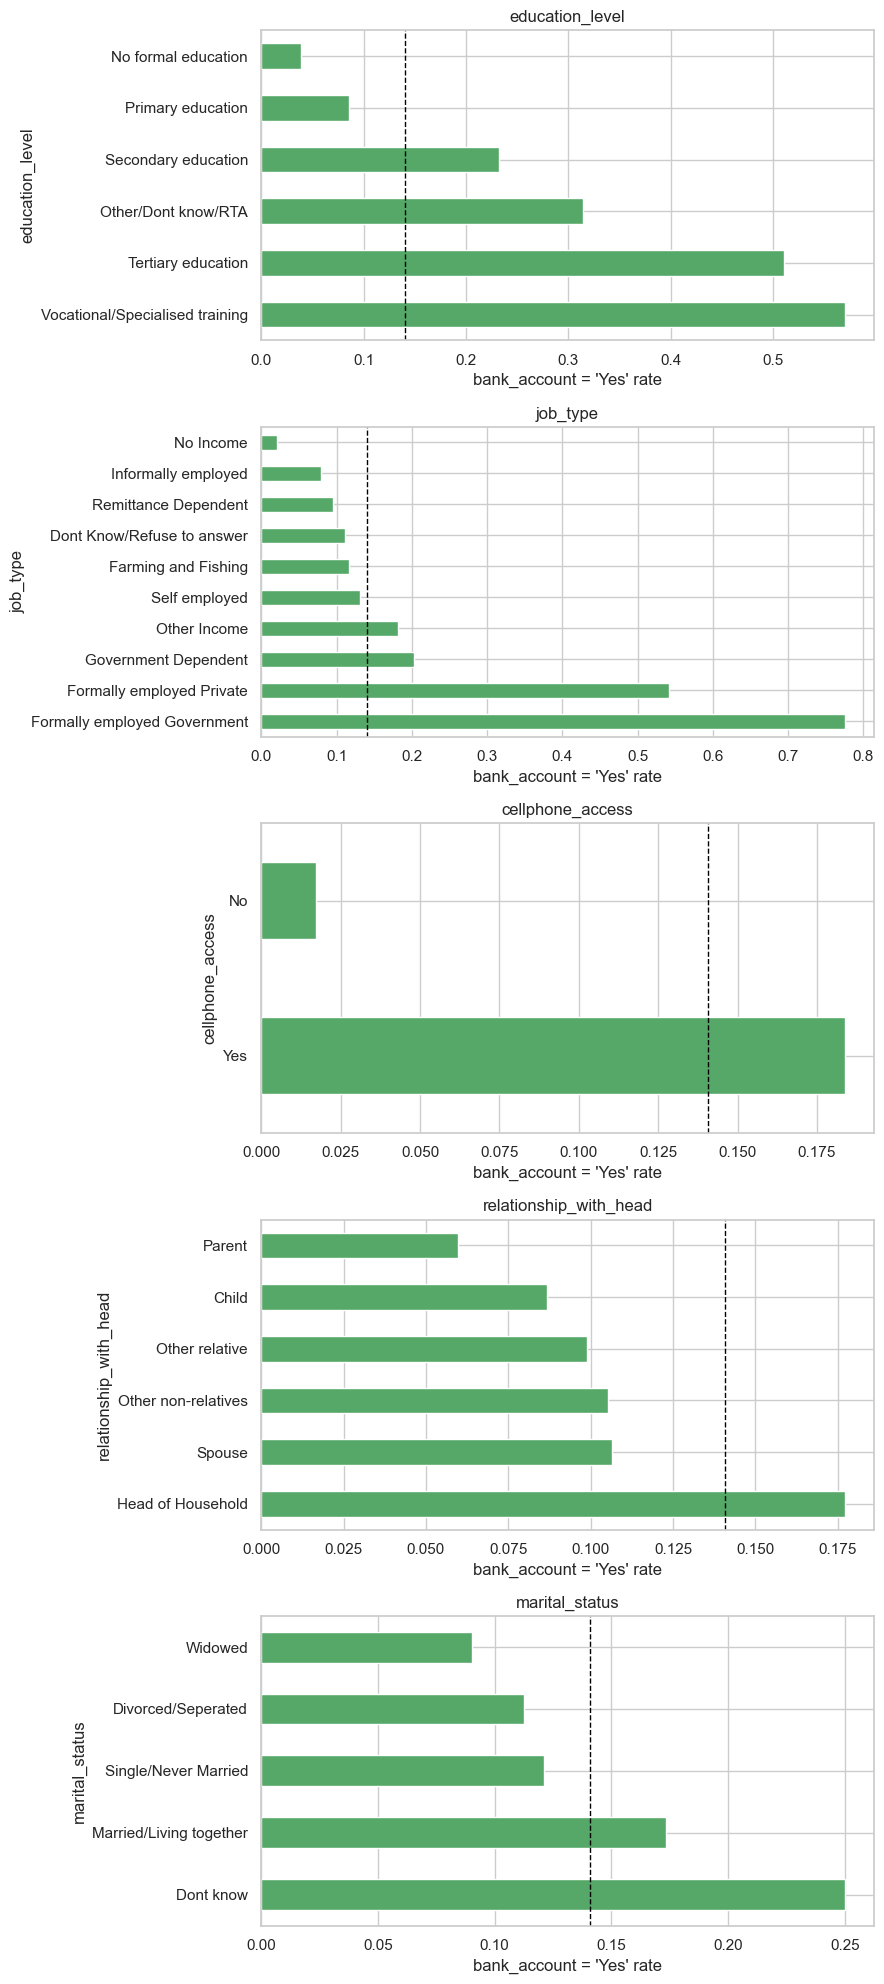

In [5]:
bivariate_cols = [
    "education_level", "job_type", "cellphone_access",
    "relationship_with_head", "marital_status",
]

fig, axes = plt.subplots(len(bivariate_cols), 1, figsize=(9, 4 * len(bivariate_cols)))
for ax, col in zip(axes, bivariate_cols):
    rate = (
        train.groupby(col)[TARGET]
        .apply(lambda s: (s == "Yes").mean())
        .sort_values(ascending=False)
    )
    rate.plot.barh(ax=ax, color="#55A868")
    ax.set_xlabel("bank_account = 'Yes' rate")
    ax.set_title(col)
    ax.axvline(target_yes_rate_overall, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

**Decision fed:** `cellphone_access` and `education_level` show the
largest separation between levels — confirms the Kenya/M-Pesa hypothesis
at the individual-feature level (having a phone strongly correlates with
having an account) and marks these as the categoricals most likely to
dominate SHAP importance in Phase 4.8. `relationship_with_head` and
`marital_status` show flatter, more overlapping rates — a first hint
toward the redundancy checked directly in 1.9.

## 1.5 — household_size and age_of_respondent vs. target (binned)

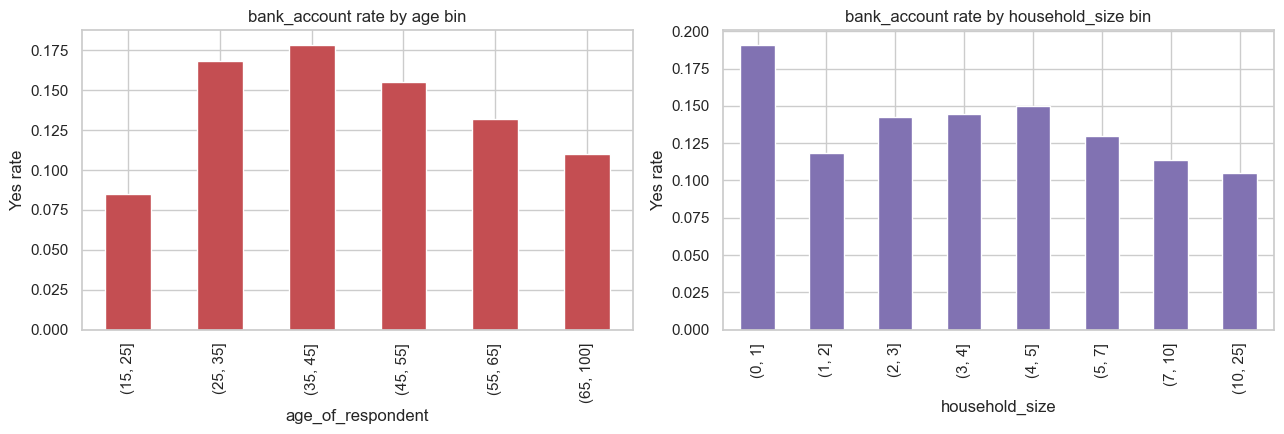

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

age_bins = pd.cut(train["age_of_respondent"], bins=[15, 25, 35, 45, 55, 65, 100])
age_rate = train.groupby(age_bins, observed=True)[TARGET].apply(lambda s: (s == "Yes").mean())
age_rate.plot.bar(ax=axes[0], color="#C44E52")
axes[0].set_title("bank_account rate by age bin")
axes[0].set_ylabel("Yes rate")

hh_bins = pd.cut(train["household_size"], bins=[0, 1, 2, 3, 4, 5, 7, 10, 25])
hh_rate = train.groupby(hh_bins, observed=True)[TARGET].apply(lambda s: (s == "Yes").mean())
hh_rate.plot.bar(ax=axes[1], color="#8172B2")
axes[1].set_title("bank_account rate by household_size bin")
axes[1].set_ylabel("Yes rate")

plt.tight_layout()
plt.show()

**Decision fed:** account ownership peaks in working-age bins (25-55) and
falls off for both the youngest and oldest respondents — a non-monotonic,
non-linear relationship that logistic regression (linear in the logit for
untransformed age) cannot capture but a tree or MLP can. Confirms
`LogisticRegressionModel`'s explicit role in Phase 3 is a sanity-check
floor, not a competitive model. `household_size` shows a much weaker,
noisier relationship.

## 1.6 — household_size outlier sanity check

In [7]:
outliers = train[train["household_size"] > 15]
print(f"n rows with household_size > 15: {len(outliers)}")
display(outliers[["country", "household_size", "age_of_respondent", TARGET]])
print()
print(train["household_size"].describe())

n rows with household_size > 15: 8


,country,household_size,age_of_respondent,bank_account
372,Kenya,16,33,No
1148,Kenya,16,33,No
4224,Kenya,21,59,No
21912,Uganda,18,31,No
22064,Uganda,17,70,Yes
22392,Uganda,20,28,No
22777,Uganda,16,28,No
22778,Uganda,16,24,No



count    23524.000000
mean         3.797483
std          2.227613
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         21.000000
Name: household_size, dtype: float64


**Decision fed:** these 8 rows are spread across multiple countries with
plausible respondent ages (not obvious data-entry artifacts like age=0 or
duplicated rows) — extended households are a real phenomenon in this
context. Confirms Phase 2.3's decision to *flag*, not drop or cap, these
rows.

## 1.7 — Cardinality audit

In [8]:
audit = cardinality_audit(train, CATEGORICAL_COLS)
display(audit)

job_type                  10
relationship_with_head     6
education_level            6
marital_status             5
country                    4
gender_of_respondent       2
location_type              2
cellphone_access           2
dtype: int64

**Decision fed:** `job_type` (10 levels) and `relationship_with_head` (6
levels) are the two highest-cardinality columns. This directly motivates
Phase 2.4's two-branch encoding: one-hot is cheap and interpretable at this
cardinality for XGBoost, but embeddings give the PyTorch branch a genuine
lower-dimensional, learned representation to compare against — this
wouldn't be as interesting an ablation axis for the binary columns
(`cellphone_access`, `location_type`, `gender_of_respondent`).

## 1.8 — Train/test category consistency check

In [9]:
consistency_report = check_train_test_category_consistency(train, test, CATEGORICAL_COLS)
for col, unseen in consistency_report.unseen_in_test.items():
    status = "no unseen categories" if not unseen else f"UNSEEN: {unseen}"
    print(f"{col}: {status}")
print()
print(f"Any unseen categories at all: {consistency_report.has_unseen_categories}")

country: no unseen categories
location_type: no unseen categories
cellphone_access: no unseen categories
gender_of_respondent: no unseen categories
relationship_with_head: no unseen categories
marital_status: no unseen categories
education_level: no unseen categories
job_type: no unseen categories

Any unseen categories at all: False


**Decision fed:** no test-set category is absent from train for this
particular train/test split, so Phase 2.5's unseen-category handling isn't
exercised by this test set — but it's still implemented and tested,
because it's a correctness requirement for the pipeline in general (a
future retrain on new data, or k-fold splits during CV, can easily produce
folds with genuinely unseen categories even when the full train/test split
happens not to).

## 1.9 — relationship_with_head × marital_status crosstab

In [10]:
crosstab = pd.crosstab(train["relationship_with_head"], train["marital_status"], normalize="index").mul(100).round(1)
display(crosstab)

marital_status,Divorced/Seperated,Dont know,Married/Living together,Single/Never Married,Widowed
relationship_with_head,,,,,
Child,9.5,0.0,4.5,82.9,3.1
Head of Household,9.1,0.0,45.1,25.8,19.9
Other non-relatives,23.7,0.0,6.3,67.9,2.1
Other relative,27.5,0.1,13.0,54.2,5.1
Parent,42.2,0.0,9.7,44.5,3.7
Spouse,0.1,0.0,71.5,28.3,0.1


**Decision fed:** there's a strong but *not total* overlap — e.g. "Head of
Household" is 45.1% Married and 19.9% Widowed (consistent with the
suspected redundancy), but also 25.8% Single and 9.1% Divorced; "Spouse"
is mostly Married (71.5%) but 28.3% Single. Each `relationship_with_head`
level spans multiple `marital_status` values rather than mapping to one.
Per Phase 2.7's conditional rule, this partial-not-total overlap does not
clear the bar for engineering a combined feature — both columns are kept
separately, since collapsing them would lose the non-redundant variation.

## 1.10 — uniqueid uniqueness check (composite key confirmation)

In [11]:
report = check_key_uniqueness(train)
print(report)
print()
print(f"uniqueid alone is a valid key: {report.uniqueid_alone_is_unique}")
print(f"uniqueid+country+year is a valid key: {report.composite_key_is_unique}")

KeyUniquenessReport(n_rows=23524, n_duplicates_on_uniqueid_alone=14789, n_duplicates_on_composite_key=0)

uniqueid alone is a valid key: False
uniqueid+country+year is a valid key: True


**Decision fed:** confirms `uniqueid` repeats across country/year (14,789
duplicate `uniqueid` values on their own) while `uniqueid+country+year` has
zero duplicates. This is enforced as a hard invariant in
`DataLoader._validate_composite_key` (Phase 2.1) so the join bug this task
is named for can never silently reach downstream code.

## Summary

See `reports/eda_summary.md` for the consolidated write-up of every
finding above and the Phase 2 decision it produced.